In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import json
import os
import time
from typing import Sequence, Tuple
import numpy as np
import jax
import jax.numpy as jnp
from jaxued.environments.underspecified_env import EnvParams, EnvState, UnderspecifiedEnv
from jaxued.utils import compute_max_mean_returns_epcount, compute_max_mean_returns_epcount_w_idxs
import optax
from flax import struct
from flax.training.train_state import TrainState as BaseTrainState
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
import distrax
import orbax.checkpoint as ocp
import wandb
from jaxued.environments.maze.env_editor import MazeEditor, Observation, ObservedMazeEditor, ObservedMazeEditorWithGoal
from jaxued.linen import ResetRNN
from jaxued.environments import Maze, MazeRenderer, ObservedMazeRenderer
from jaxued.environments.maze import Level, ObservedLevel
from jaxued.wrappers import AutoReplayWrapper
import chex

import logging
import hydra
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt

In [21]:
from omegaconf import OmegaConf
from hydra import initialize, compose


def load_hydra_config(config_path, config_name):
    # Initialize the Hydra context
    with initialize(config_path=config_path):
        # Compose the configuration
        cfg = compose(config_name=config_name)
        return cfg
    
config_path = "config"  # path to the directory containing the config file
config_name = "main_paired"  # name of the config file without the extension

config = load_hydra_config(config_path, config_name)

if config["num_env_steps"] is not None:
    config["num_updates"] = config["num_env_steps"] // (config["num_train_envs"] * config["num_steps"])

if config['mode'] == 'eval':
    os.environ['WANDB_MODE'] = 'disabled'
    

/tmp/ipykernel_399306/2007320477.py:7: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=config_path):


In [22]:
# region PPO helper functions    
@struct.dataclass
class TrainState:
    update_count: int
    pro_train_state: BaseTrainState
    ant_train_state: BaseTrainState
    adv_train_state: BaseTrainState

def compute_gae(
    gamma: float,
    lambd: float,
    last_value: chex.Array,
    values: chex.Array,
    rewards: chex.Array,
    dones: chex.Array,
    traj_idxs: chex.Array
) -> Tuple[chex.Array, chex.Array]:
    """This takes in arrays of shape (NUM_STEPS, NUM_ENVS) and returns the advantages and targets.

    Args:
        gamma (float): 
        lambd (float): 
        last_value (chex.Array):  Shape (NUM_ENVS)
        values (chex.Array): Shape (NUM_STEPS, NUM_ENVS)
        rewards (chex.Array): Shape (NUM_STEPS, NUM_ENVS)
        dones (chex.Array): Shape (NUM_STEPS, NUM_ENVS)

    Returns:
        Tuple[chex.Array, chex.Array]: advantages, targets; each of shape (NUM_STEPS, NUM_ENVS)
    """
    def compute_gae_at_timestep(carry, x):
        gae, next_value, cur_idx = carry
        traj_started = cur_idx <= traj_idxs
    
        value, reward, done = x
        delta = reward + gamma * next_value * (1 - done) * traj_started - value
        gae = delta + gamma * lambd * (1 - done) * gae
        return (gae, jnp.where(traj_started, value, next_value), cur_idx - 1), gae

    _, advantages = jax.lax.scan(
        compute_gae_at_timestep,
        (jnp.zeros_like(last_value), last_value, values.shape[0]),
        (values, rewards, dones),
        reverse=True,
        unroll=16,
    )
    return advantages, advantages + values


class ActorCritic(nn.Module):
    action_dim: Sequence[int]
    
    @nn.compact
    def __call__(self, inputs, hidden):
        obs, dones = inputs
        
        img_embed = nn.Conv(16, kernel_size=(3, 3), strides=(1, 1), padding="VALID")(obs.image)
        img_embed = img_embed.reshape(*img_embed.shape[:-3], -1)
        img_embed = nn.relu(img_embed)
        
        dir_embed = jax.nn.one_hot(obs.agent_dir, 4)
        dir_embed = nn.Dense(5, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0), name="scalar_embed")(dir_embed)
        
        embedding = jnp.append(img_embed, dir_embed, axis=-1)

        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)

        actor_mean = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="actor0")(embedding)
        actor_mean = nn.tanh(actor_mean)
        actor_mean = nn.Dense(self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0), name="actor1")(actor_mean)
        pi = distrax.Categorical(logits=actor_mean)

        critic = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="critic0")(embedding)
        critic = nn.relu(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0), name="critic1")(critic)

        return hidden, pi, jnp.squeeze(critic, axis=-1)
    
    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))


class AdversaryActorCritic(nn.Module):
    # The adversary's network architecture
    action_dim: Sequence[int]
    max_timesteps: int = 50
    
    @nn.compact
    def __call__(self, inputs: Tuple[Observation, chex.Array], hidden):
        obs, dones = inputs
        
        img_embed = nn.Conv(128, kernel_size=(3, 3), strides=(1, 1), padding="VALID")(jnp.concatenate((obs.image, jnp.expand_dims(obs.observation_map, axis=-1), obs.agent_observations), axis=-1))
        img_embed = img_embed.reshape(*img_embed.shape[:-3], -1)
        img_embed = nn.relu(img_embed)
        
        time_value = nn.Embed(self.max_timesteps + 1, 10, name="time_embed", embedding_init=orthogonal(1.0))(jnp.clip(obs.time, None, self.max_timesteps))
        random_z_value = obs.random_z
        embedding = jnp.concatenate((img_embed, time_value, random_z_value, obs.place_goal[..., None]), axis=-1)

        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)

        actor_mean = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="actor0")(embedding)
        actor_mean = nn.relu(actor_mean)
        actor_mean = nn.Dense(self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0), name="actor1")(actor_mean)

        # Mask out this
        actor_mean = jnp.where(obs.action_mask, actor_mean, -jnp.inf)
        pi = distrax.Categorical(logits=actor_mean)

        critic = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="critic0")(embedding)
        critic = nn.relu(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0), name="critic1")(critic)

        return hidden, pi, jnp.squeeze(critic, axis=-1)
    
    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))

In [23]:
env = Maze(max_height=13, max_width=13, agent_view_size=5, normalize_obs=True)
adv_env = ObservedMazeEditorWithGoal(env, random_z_dimensions=config['adv_random_z_dimension'], zero_out_random_z=config['adv_zero_out_random_z'])
adv_env_renderer = ObservedMazeRenderer(env, tile_size=8)
env_renderer = MazeRenderer(env, tile_size=8)
env = AutoReplayWrapper(env)
env_params = env.default_params
adv_env_params = adv_env.default_params

rng = jax.random.PRNGKey(14532)
rng, _rng = jax.random.split(rng)

In [24]:
def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        observation_map=jnp.zeros((h, w), dtype=jnp.bool_),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([1, 1], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

def create_train_state(rng):
    def create_inner_train_state(rng, env, env_params, network_cls, prefix, network_kws={}):
        def linear_schedule(count):
            frac = (
                1.0
                - (count // (config[f"{prefix}num_minibatches"] * config[f"{prefix}epoch_ppo"]))
                / config["num_updates"]
            )
            return config[f"{prefix}lr"] * frac
        obs, _ = env.reset_to_level(rng, sample_empty_level(), env_params)
        obs = jax.tree_map(
            lambda x: jnp.repeat(jnp.repeat(x[None, ...], config["num_train_envs"], axis=0)[None, ...], 256, axis=0),
            obs,
        )
        init_x = (obs, jnp.zeros((256, config["num_train_envs"])))
        network = network_cls(env.action_space(env_params).n, **network_kws)
        network_params = network.init(rng, init_x, network_cls.initialize_carry((config["num_train_envs"],)))
        tx = optax.chain(
            optax.clip_by_global_norm(config[f"{prefix}max_grad_norm"]),
            optax.adam(learning_rate=linear_schedule, eps=1e-5),
            # optax.adam(learning_rate=config[f"{prefix}lr"], eps=1e-5),
        )
        return BaseTrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )
    rng_pro, rng_ant, rng_adv = jax.random.split(rng, 3)
    return TrainState(
        update_count = 0,
        pro_train_state = create_inner_train_state(rng_pro, env, env_params, ActorCritic, "student_"),
        ant_train_state = create_inner_train_state(rng_ant, env, env_params, ActorCritic, "student_"),
        adv_train_state = create_inner_train_state(rng_adv, adv_env, adv_env_params, AdversaryActorCritic, "adv_", network_kws={"max_timesteps": config["adv_num_steps"]})
    )

In [25]:
rng, _rng = jax.random.split(rng)
train_state = create_train_state(_rng)

# Adv Environment

In [32]:
def sample_trajectories(
    rng: chex.PRNGKey,
    env: UnderspecifiedEnv,
    env_params: EnvParams,
    adv_env: UnderspecifiedEnv,
    adv_env_params: EnvParams,
    train_state: TrainState,
    init_levels: ObservedLevel,
    num_envs: int,
    max_episode_length: int,
    max_adv_episode_length: int,
):

    pro_train_state = train_state.pro_train_state
    ant_train_state = train_state.ant_train_state
    adv_train_state = train_state.adv_train_state


    rng, _rng = jax.random.split(rng)
    adv_init_obs, adv_init_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), init_levels, adv_env_params)
    init_student_obs_mask = jnp.ones((num_envs, adv_env.action_space(adv_env_params).n), dtype=jnp.bool_)

    # Create Padded Trajectory accounting for max size of adversary trajectory
    adv_init_traj = (
        adv_init_obs, 
        jnp.zeros(num_envs, dtype=jnp.int32),
        jnp.zeros(num_envs, dtype=jnp.int32),
        jnp.zeros(num_envs, dtype=jnp.bool_),
        jnp.zeros(num_envs, dtype=jnp.float32),
        jnp.zeros(num_envs, dtype=jnp.float32),
        {}
    )

    def pad_traj(input_array: chex.Array):
        return jnp.stack([input_array] + [jnp.zeros_like(input_array)] * (max_adv_episode_length - 1))

    adv_traj_idxs = jnp.zeros(num_envs, dtype=jnp.int32)
    adv_init_traj = jax.tree_map(pad_traj, adv_init_traj)

    # Student Step in Env
    def sample_student_step(carry, _):
        rng, train_state, hstate, obs, env_state, last_done = carry
        rng, rng_action, rng_step = jax.random.split(rng, 3)

        x = jax.tree_map(lambda x: x[None, ...], (obs, last_done))
        hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
        action = pi.sample(seed=rng_action)
        log_prob = pi.log_prob(action)
        value, action, log_prob = (
            value.squeeze(0),
            action.squeeze(0),
            log_prob.squeeze(0),
        )

        next_obs, env_state, reward, done, info = jax.vmap(
            env.step, in_axes=(0, 0, 0, None)
        )(jax.random.split(rng_step, num_envs), env_state, action, env_params)

        carry = (rng, train_state, hstate, next_obs, env_state, done)
        return carry, (obs, action, reward, done, log_prob, value, info)

    # Adversary Step in Env
    def sample_adv_step(carry):
        # Env Step that Updates Action Mask
        def env_step(rng, state, action, params, student_obs_mask, student_observations):
            next_obs, env_state, reward, done, info = adv_env.step(rng, state, action, params)
            action_mask = jnp.logical_and(next_obs.action_mask, student_obs_mask)
            return next_obs.replace(action_mask=action_mask, agent_observations=student_observations, place_goal=jnp.array(False, dtype=jnp.bool_)), env_state, reward, done, info

        rng, train_state, hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs = carry
        rng, rng_action, rng_step = jax.random.split(rng, 3)

        # Check which envs still have remaining actions
        keep_gen = ~jnp.all(~obs.action_mask, axis=1)
        
        traj_not_full = adv_traj_idxs < max_adv_episode_length
        keep_gen = jnp.logical_and(keep_gen, traj_not_full)

        x = jax.tree_map(lambda x: x[None, ...], (obs, last_done))
        next_hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
        action = pi.sample(seed=rng_action)
        log_prob = pi.log_prob(action)
        value, action, log_prob = (
            value.squeeze(0),
            action.squeeze(0),
            log_prob.squeeze(0),
        )

        next_obs, next_env_state, reward, done, info = jax.vmap(
            env_step, in_axes=(0, 0, 0, None, 0, 0)
        )(jax.random.split(rng_step, num_envs), env_state, action, env_params, student_obs_mask, student_observations)

        traj_step = (obs, action, reward, done, log_prob, value, info)
        
        # Add next trajectory step to the full padded traj if action was available
        def update_traj(full_traj, traj_step):
            def update_at_idx(full_traj, traj_step, idx, keep_gen):
                return jax.lax.cond(keep_gen,
                    lambda : jax.lax.dynamic_update_slice_in_dim(full_traj, traj_step[None, ...], idx, 0),
                    lambda : full_traj
                )
            
            return jax.vmap(
                update_at_idx, in_axes=(1, 0, 0, 0)
            )(full_traj, traj_step, adv_traj_idxs, keep_gen).swapaxes(1, 0)

        adv_full_traj = jax.tree_map(update_traj, adv_full_traj, traj_step)

        # Replace Carry for envs with available actions
        def replace_carry(new, old):
            expanded_keep_gen = jnp.reshape(keep_gen, (keep_gen.shape[0],) + (1,) * (new.ndim - 1))
            return jnp.where(expanded_keep_gen, new, old)
        
        (next_hstate, next_obs, next_env_state, done, adv_traj_idxs) = jax.tree_map(
            replace_carry,
            (next_hstate, next_obs, next_env_state, done, adv_traj_idxs + 1),
            (hstate, obs, env_state, last_done, adv_traj_idxs)
        )
        
        carry = (
            rng, 
            train_state, 
            next_hstate, 
            next_obs, 
            next_env_state, 
            done, 
            student_obs_mask, 
            student_observations,
            adv_full_traj, 
            adv_traj_idxs
        )
        return carry

    (
        rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs
    ) = jax.lax.while_loop(
        lambda carry : (carry[-1] < 2).all(),
        sample_adv_step,
        (
            rng,
            adv_train_state,
            AdversaryActorCritic.initialize_carry((num_envs,)),
            adv_init_obs,
            adv_init_env_state,
            jnp.zeros(num_envs, dtype=bool),
            init_student_obs_mask,
            adv_init_obs.agent_observations,
            adv_init_traj,
            adv_traj_idxs
        ),
    )

    # Initialise Student
    rng, _rng = jax.random.split(rng)
    init_obs, init_env_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), adv_last_env_state.level, env_params)

    pro_carry = (
        pro_train_state, 
        ActorCritic.initialize_carry((num_envs,)), 
        init_obs, 
        init_env_state, 
        jnp.zeros(num_envs, dtype=bool)
    )

    ant_carry = (
        ant_train_state, 
        ActorCritic.initialize_carry((num_envs,)), 
        init_obs, 
        init_env_state, 
        jnp.zeros(num_envs, dtype=bool)
    )

    adv_carry = (
        adv_train_state, 
        adv_hstate, 
        adv_last_obs, 
        adv_last_env_state, 
        adv_last_done, 
        student_obs_mask, 
        adv_full_traj, 
        adv_traj_idxs
    )

    # get adversary action 
    def sample_step(carry, _):
        rng, pro_carry, ant_carry, adv_carry, (adv_pro_rewards, adv_ant_rewards), (pro_val, pro_avg, pro_eps, ant_val, ant_max) = carry

        pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done = pro_carry
        ant_train_state, ant_hstate, ant_obs, ant_env_state, ant_last_done = ant_carry
        adv_train_state, adv_hstate, _, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs = adv_carry
        adv_last_obs = jax.vmap(adv_env.get_obs, in_axes=(0, 0))(jax.random.split(_rng, num_envs), adv_last_env_state)

        student_observations = jnp.stack([pro_obs.agent_observation, ant_obs.agent_observation], axis=3)
        student_obs_mask = jnp.concatenate([jnp.logical_or(student_observations[:, :, :, 0], student_observations[:, :, :, 1]).reshape(num_envs, -1)]*3, axis=1)
        action_mask = jnp.logical_and(adv_last_obs.action_mask, student_obs_mask)

        # Prevent Goal Placing on all but the first action of the set
        student_obs_mask = jnp.logical_and(student_obs_mask, jnp.concatenate([jnp.ones((num_envs, adv_env.action_space(adv_env_params).n * 2 // 3)), jnp.zeros((num_envs, adv_env.action_space(adv_env_params).n // 3))], axis=1))

        (
            (rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs)
        ) = jax.lax.while_loop(
            lambda carry : ~jnp.logical_or(jnp.all(~carry[3].action_mask, axis=1), ~(carry[9] < max_adv_episode_length)).all(),
            #lambda carry : ~(~carry[3].action_mask).all()
            sample_adv_step,
            (
                rng,
                adv_train_state,
                adv_hstate,
                adv_last_obs.replace(action_mask=action_mask, agent_observations=student_observations),
                adv_last_env_state,
                adv_last_done,
                student_obs_mask,
                student_observations,
                adv_full_traj,
                adv_traj_idxs
            )
        )

        # update student envs
        pro_obs, pro_env_state = jax.vmap(env.update_state_from_level, in_axes=(0, 0))(adv_last_env_state.level, pro_env_state)
        ant_obs, ant_env_state = jax.vmap(env.update_state_from_level, in_axes=(0, 0))(adv_last_env_state.level, ant_env_state)

        # students act in env
        full_pro_carry, pro_traj_step = sample_student_step(
            (rng, pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done), 
            None
        )
        rng, pro_carry = full_pro_carry[0], full_pro_carry[1:]
        pro_reward, pro_done = pro_traj_step[2:4]

        pro_val = pro_val + pro_reward
        new_pro_avg = pro_avg + pro_done * ((pro_val - pro_avg) / (pro_eps + 1))
        pro_eps = pro_eps + pro_done
        pro_avg_change = new_pro_avg - pro_avg
        pro_avg = new_pro_avg
        pro_val = (1 - pro_done) * pro_val

        full_ant_carry, ant_traj_step = sample_student_step(
            (rng, ant_train_state, ant_hstate, ant_obs, ant_env_state, ant_last_done), 
            None
        )
        rng, ant_carry = full_ant_carry[0], full_ant_carry[1:]
        ant_reward, ant_done = ant_traj_step[2:4]
        
        ant_val = ant_val + ant_reward
        new_ant_max = (1 - ant_done) * ant_max + ant_done * jnp.maximum(ant_max, ant_val)
        ant_max_change = new_ant_max - ant_max
        ant_max = new_ant_max
        ant_val = (1 - ant_done) * ant_val


        def add_at_idx(arr, add, idx):
            old_val = jax.lax.dynamic_index_in_dim(arr, idx-1, axis=0)
            return jax.lax.dynamic_update_index_in_dim(arr, add + old_val, idx-1, axis=0)
            
        (adv_pro_rewards, adv_ant_rewards) = jax.tree_map(
            lambda r, a : jax.vmap(add_at_idx, in_axes=(1, 0, 0))(r, a, adv_traj_idxs).swapaxes(0, 1),
            (adv_pro_rewards, adv_ant_rewards), (pro_avg_change, ant_max_change)
        )

        # Return Carry
        adv_carry = (adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs)
        carry = (rng, pro_carry, ant_carry, adv_carry, (adv_pro_rewards, adv_ant_rewards), (pro_val, pro_avg, pro_eps, ant_val, ant_max))

        return carry, (pro_traj_step, ant_traj_step, adv_traj_idxs)

    empty_rewards = jnp.zeros((max_adv_episode_length, num_envs))
    empty_stats = jnp.zeros(num_envs)

    (rng, pro_carry, ant_carry, adv_carry, (adv_pro_rewards, adv_ant_rewards), _), (pro_traj, ant_traj, adv_traj_idx_array) = jax.lax.scan(
        sample_step, 
        (rng, pro_carry, ant_carry, adv_carry, (empty_rewards, empty_rewards), (empty_stats, empty_stats, empty_stats, empty_stats, empty_stats)), 
        None, 
        length=max_episode_length
    )

    def get_last_value(carry):
        train_state, hstate, last_obs, _, last_done = carry[:5]
        x = jax.tree_map(lambda x: x[None, ...], (last_obs, last_done))
        _, _, last_value = train_state.apply_fn(train_state.params, x, hstate)
        return last_value

    last_values = get_last_value(pro_carry).squeeze(0), get_last_value(ant_carry).squeeze(0), get_last_value(adv_carry).squeeze(0)

    return rng, (pro_carry[:4], ant_carry[:4], adv_carry[:4]), (pro_traj, ant_traj, adv_carry[6:]), last_values, (adv_pro_rewards, adv_ant_rewards, adv_traj_idx_array)

In [27]:
def masked_mean(arr, mask):
    return jnp.sum(arr * mask) / jnp.sum(mask)

def masked_std(arr, mask):
    mean = masked_mean(arr, mask)
    var = jnp.sum(mask*(arr - mean)**2)/jnp.sum(mask)
    return jnp.sqrt(var)

def update_actor_critic_rnn(
    rng: chex.PRNGKey,
    train_state: TrainState,
    init_hstate: chex.ArrayTree,
    batch: chex.ArrayTree,
    num_envs: int,
    n_steps: int,
    n_minibatch: int,
    n_epochs: int,
    clip_eps: float,
    entropy_coeff: float,
    critic_coeff: float,
    update_grad: bool=True,
) -> Tuple[Tuple[chex.PRNGKey, TrainState], chex.ArrayTree]:
    """This function takes in a rollout, and PPO hyperparameters, and updates the train state.

    Args:
        rng (chex.PRNGKey): 
        train_state (TrainState): 
        init_hstate (chex.ArrayTree): 
        batch (chex.ArrayTree): obs, actions, dones, log_probs, values, targets, advantages
        num_envs (int): 
        n_steps (int): 
        n_minibatch (int): 
        n_epochs (int): 
        clip_eps (float): 
        entropy_coeff (float): 
        critic_coeff (float): 
        update_grad (bool, optional): If False, the train state does not actually get updated. Defaults to True.

    Returns:
        Tuple[Tuple[chex.PRNGKey, TrainState], chex.ArrayTree]: It returns a new rng, the updated train_state, and the losses. The losses have structure (loss, (l_vf, l_clip, entropy))
    """
    obs, actions, dones, log_probs, values, targets, advantages, update_mask = batch
    last_dones = jnp.roll(dones, 1, axis=0).at[0].set(False)
    batch = obs, actions, last_dones, log_probs, values, targets, advantages, update_mask
    
    def update_epoch(carry, _):
        def update_minibatch(train_state, minibatch):
            init_hstate, obs, actions, last_dones, log_probs, values, targets, advantages, update_mask = minibatch
            
            def loss_fn(params):
                _, pi, values_pred = train_state.apply_fn(params, (obs, last_dones), init_hstate)
                log_probs_pred = pi.log_prob(actions)
                entropy = masked_mean(pi.entropy(), update_mask)

                ratio = jnp.exp(log_probs_pred - log_probs)
                A = (advantages - masked_mean(advantages, update_mask)) / (masked_std(advantages, update_mask) + 1e-5)
                l_clip = masked_mean((-jnp.minimum(ratio * A, jnp.clip(ratio, 1 - clip_eps, 1 + clip_eps) * A)), update_mask)

                values_pred_clipped = values + (values_pred - values).clip(-clip_eps, clip_eps)
                l_vf = masked_mean(0.5 * jnp.maximum((values_pred - targets) ** 2, (values_pred_clipped - targets) ** 2), update_mask)

                loss = l_clip + critic_coeff * l_vf - entropy_coeff * entropy

                return loss, (l_vf, l_clip, entropy)

            grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
            loss, grads = grad_fn(train_state.params)
            if update_grad:
                train_state = train_state.apply_gradients(grads=grads)
            return train_state, loss

        rng, train_state = carry
        rng, rng_perm = jax.random.split(rng)
        permutation = jax.random.permutation(rng_perm, num_envs)
        minibatches = (
            jax.tree_map(
                lambda x: jnp.take(x, permutation, axis=0)
                .reshape(n_minibatch, -1, *x.shape[1:]),
                init_hstate,
            ),
            *jax.tree_map(
                lambda x: jnp.take(x, permutation, axis=1)
                .reshape(x.shape[0], n_minibatch, -1, *x.shape[2:])
                .swapaxes(0, 1),
                batch,
            ),
        )
        train_state, losses = jax.lax.scan(update_minibatch, train_state, minibatches)
        return (rng, train_state), losses

    return jax.lax.scan(update_epoch, (rng, train_state), None, n_epochs)

def update(rng, train_state, init_hstate, rollout, prefix):
    # Returns: (rng, train_state), losses
    return update_actor_critic_rnn(
        rng,
        train_state,
        init_hstate,
        rollout,
        config["num_train_envs"],
        config[f"{prefix}num_steps"],
        config[f"{prefix}num_minibatches"],
        config[f"{prefix}epoch_ppo"],
        config[f"{prefix}clip_eps"],
        config[f"{prefix}entropy_coeff"],
        config[f"{prefix}critic_coeff"],
        update_grad=True,
    )

In [28]:
def update_actor_critic_rnn_kl(
    rng: chex.PRNGKey,
    train_state: TrainState,
    kl_train_state: TrainState,
    init_hstate: chex.ArrayTree,
    batch: chex.ArrayTree,
    num_envs: int,
    n_steps: int,
    n_minibatch: int,
    n_epochs: int,
    clip_eps: float,
    entropy_coeff: float,
    critic_coeff: float,
    kl_coeff: float,
    kl_mask: chex.Array,
    update_grad: bool=True,
) -> Tuple[Tuple[chex.PRNGKey, TrainState], chex.ArrayTree]:
    """This function takes in a rollout, and PPO hyperparameters, and updates the train state.

    Args:
        rng (chex.PRNGKey): 
        train_state (TrainState): 
        init_hstate (chex.ArrayTree): 
        batch (chex.ArrayTree): obs, actions, dones, log_probs, values, targets, advantages
        num_envs (int): 
        n_steps (int): 
        n_minibatch (int): 
        n_epochs (int): 
        clip_eps (float): 
        entropy_coeff (float): 
        critic_coeff (float): 
        update_grad (bool, optional): If False, the train state does not actually get updated. Defaults to True.

    Returns:
        Tuple[Tuple[chex.PRNGKey, TrainState], chex.ArrayTree]: It returns a new rng, the updated train_state, and the losses. The losses have structure (loss, (l_vf, l_clip, entropy))
    """
    obs, actions, dones, log_probs, values, targets, advantages, update_mask = batch
    last_dones = jnp.roll(dones, 1, axis=0).at[0].set(False)
    _, kl_pi, _ = kl_train_state.apply_fn(kl_train_state.params, (obs, last_dones), init_hstate)
    batch = obs, actions, last_dones, log_probs, values, targets, advantages, update_mask, kl_pi
    
    def update_epoch(carry, _):
        def update_minibatch(train_state, minibatch):
            init_hstate, kl_mask, obs, actions, last_dones, log_probs, values, targets, advantages, update_mask, kl_pi = minibatch
            
            def loss_fn(params):
                _, pi, values_pred = train_state.apply_fn(params, (obs, last_dones), init_hstate)
                log_probs_pred = pi.log_prob(actions)
                entropy = masked_mean(pi.entropy(), update_mask)
                kl_divergence = masked_mean(kl_pi.kl_divergence(pi) * kl_mask, update_mask)

                ratio = jnp.exp(log_probs_pred - log_probs)
                A = (advantages - masked_mean(advantages, update_mask)) / (masked_std(advantages, update_mask) + 1e-5)
                l_clip = masked_mean((-jnp.minimum(ratio * A, jnp.clip(ratio, 1 - clip_eps, 1 + clip_eps) * A)), update_mask)

                values_pred_clipped = values + (values_pred - values).clip(-clip_eps, clip_eps)
                l_vf = masked_mean(0.5 * jnp.maximum((values_pred - targets) ** 2, (values_pred_clipped - targets) ** 2), update_mask)

                loss = l_clip + critic_coeff * l_vf - entropy_coeff * entropy + kl_coeff * kl_divergence

                return loss, (l_vf, l_clip, entropy, kl_divergence)

            grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
            loss, grads = grad_fn(train_state.params)
            if update_grad:
                train_state = train_state.apply_gradients(grads=grads)
            return train_state, loss

        rng, train_state = carry
        rng, rng_perm = jax.random.split(rng)
        permutation = jax.random.permutation(rng_perm, num_envs)
        minibatches = (
            *jax.tree_map(
                lambda x: jnp.take(x, permutation, axis=0)
                .reshape(n_minibatch, -1, *x.shape[1:]),
                (init_hstate, kl_mask),
            ),
            *jax.tree_map(
                lambda x: jnp.take(x, permutation, axis=1)
                .reshape(x.shape[0], n_minibatch, -1, *x.shape[2:])
                .swapaxes(0, 1),
                batch,
            ),
        )
        train_state, losses = jax.lax.scan(update_minibatch, train_state, minibatches)
        return (rng, train_state), losses

    return jax.lax.scan(update_epoch, (rng, train_state), None, n_epochs)

def update_w_kl(rng, train_state, kl_train_state, kl_mask, init_hstate, rollout, prefix):
    # Returns: (rng, train_state), losses
    return update_actor_critic_rnn_kl(
        rng,
        train_state,
        kl_train_state,
        init_hstate,
        rollout,
        config["num_train_envs"],
        config[f"{prefix}num_steps"],
        config[f"{prefix}num_minibatches"],
        config[f"{prefix}epoch_ppo"],
        config[f"{prefix}clip_eps"],
        config[f"{prefix}entropy_coeff"],
        config[f"{prefix}critic_coeff"],
        config[f"{prefix}kl_coeff"],
        kl_mask,
        update_grad=True,
    )

In [29]:
def get_rollout(traj, traj_idxs, last_value, prefix):
    obs, actions, rewards, dones, log_probs, values, info = traj
    advantages, targets = compute_gae(config[f"{prefix}gamma"], config[f"{prefix}gae_lambda"], last_value, values, rewards, dones, traj_idxs)
    update_mask = jnp.tile(jnp.arange(actions.shape[0])[:, None], (1, actions.shape[1])) < traj_idxs
    return (obs, actions, dones, log_probs, values, targets, advantages, update_mask), (dones, rewards)

In [33]:
# Initialise Levels
empty_levels = jax.tree_map(lambda x: jnp.array([x]).repeat(config["num_train_envs"], axis=0), sample_empty_level())

rng, (pro_carry, ant_carry, adv_carry), (pro_traj, ant_traj, (adv_traj, adv_traj_idxs)), (pro_last_value, ant_last_value, adv_last_value), (adv_pro_rewards, adv_ant_rewards, adv_traj_idx_array) = sample_trajectories(
    rng,
    env,
    env_params,
    adv_env,
    adv_env_params,
    train_state,
    empty_levels,
    config["num_train_envs"],
    config["student_num_steps"],
    config["adv_num_steps"]
)

In [13]:
pro_rollout, (dones, rewards) = get_rollout(pro_traj, jnp.ones(config["num_train_envs"], dtype=jnp.int32) * config["student_num_steps"], pro_last_value, 'student_')
pro_mean_returns, pro_max_returns, pro_eps = compute_max_mean_returns_epcount(dones, rewards)

# Adjusting Antagonist Reward
obs, actions, rewards, dones, log_probs, values, info = ant_traj
ant_mean_returns, ant_max_returns, ant_eps, ant_max_idxs = compute_max_mean_returns_epcount_w_idxs(dones, rewards, adv_traj_idx_array)
#rewards = rewards - (dones*pro_mean_returns)
#rewards = rewards / ((pro_mean_returns + ant_mean_returns)/2 + 1e-5)
ant_traj_adjusted = obs, actions, rewards, dones, log_probs, values, info
ant_rollout, _ = get_rollout(ant_traj_adjusted, jnp.ones(config["num_train_envs"], dtype=jnp.int32) * config["student_num_steps"], ant_last_value, 'student_')

# Adversary Rewards 
est_regret = ant_max_returns - pro_mean_returns
obs, actions, rewards, dones, log_probs, values, info = adv_traj

dones = jax.vmap(
    lambda x, i : jax.lax.dynamic_update_slice(x, jnp.ones((1,), dtype=jnp.bool_), (i-1,)),
    in_axes=(1, 0)
)(dones, adv_traj_idxs).swapaxes(0, 1)

# adv_ant_max_reward = jax.vmap(
#     lambda x, r, i : jax.lax.dynamic_update_slice(x, jnp.array([r]), (i-1,)),
#     in_axes=(1, 0, 0)
# )(jnp.zeros_like(values), ant_max_returns, ant_max_idxs.astype(jnp.int32)).swapaxes(0, 1)
#)(jnp.zeros_like(values), ant_max_returns, adv_traj_idxs).swapaxes(0, 1)

rewards = adv_ant_rewards - adv_pro_rewards

adv_traj = obs, actions, rewards, dones, log_probs, values, info
adv_rollout, _ = get_rollout(adv_traj, adv_traj_idxs, adv_last_value, 'adv_')

In [127]:
rewards.sum(axis=0)

Array([ 0.        ,  0.9784    ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.676     ,  0.        ,  0.        , -0.01619995,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.666     ,  0.        ,  0.11079997,  0.        ,
        0.03240001,  0.91719997,  0.05480003,  0.11340004,  0.        ,
        0.        ,  0.        ], dtype=float32)

In [128]:
est_regret

Array([ 0.        ,  0.9784    ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.676     ,  0.        ,  0.        , -0.01619995,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.666     ,  0.        ,  0.11079997,  0.        ,
        0.03240001,  0.91719997,  0.05480003,  0.11340004,  0.        ,
        0.        ,  0.        ], dtype=float32)

In [128]:
ant_traj_adjusted[2].sum(axis=0)/ant_eps

Array([0.8627963 , 0.        , 0.        , 1.1979356 , 0.        ,
       1.1731634 , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.98399687, 0.        , 0.        , 1.9997135 ,
       0.8900964 , 0.        , 0.        , 0.        , 0.        ,
       0.        , 1.9999548 , 1.9999487 , 0.        , 0.        ,
       0.        , 1.9998899 , 0.        , 0.        , 0.        ,
       0.        , 0.        ], dtype=float32)

In [119]:
(pro_mean_returns + ant_mean_returns)/2

Array([0.82729995, 0.        , 0.        , 0.8002    , 0.473     ,
       0.6652    , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.9311091 , 0.        , 0.        , 0.06979999,
       0.58149993, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.44276   , 0.3902    , 0.        , 0.        ,
       0.        , 0.18139997, 0.        , 0.        , 0.        ,
       0.        , 0.        ], dtype=float32)

In [120]:
pro_mean_returns

Array([0.9408    , 0.        , 0.        , 0.6417999 , 0.946     ,
       0.54999995, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.94600004, 0.        , 0.        , 0.        ,
       0.6454    , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        ], dtype=float32)

In [121]:
ant_mean_returns 

Array([0.71379995, 0.        , 0.        , 0.9586    , 0.        ,
       0.7804    , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.91621816, 0.        , 0.        , 0.13959998,
       0.51759994, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.88552   , 0.7804    , 0.        , 0.        ,
       0.        , 0.36279994, 0.        , 0.        , 0.        ,
       0.        , 0.        ], dtype=float32)

In [96]:
jnp.logical_and(adv_rollout[-1], ant_mean_returns > pro_mean_returns)[:, 3]

Array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [108]:
(rng, pro_train_state), pro_losses = update_w_kl(rng, train_state.pro_train_state, train_state.ant_train_state, ant_mean_returns > pro_mean_returns, ActorCritic.initialize_carry((config["num_train_envs"],)), pro_rollout, "student_")
(rng, ant_train_state), ant_losses = update_w_kl(rng, train_state.ant_train_state, train_state.pro_train_state, pro_max_returns > ant_max_returns, ActorCritic.initialize_carry((config["num_train_envs"],)), ant_rollout, "student_")
(rng, adv_train_state), adv_losses = update(rng, train_state.adv_train_state, AdversaryActorCritic.initialize_carry((config["num_train_envs"],)), adv_rollout, "adv_")

_, _, _, adv_last_env_state = adv_carry
levels = adv_last_env_state.level

metrics = {
    "pro_losses": jax.tree_map(lambda x: x.mean(), pro_losses),
    "ant_losses": jax.tree_map(lambda x: x.mean(), ant_losses),
    "adv_losses": jax.tree_map(lambda x: x.mean(), adv_losses),
    "mean_num_blocks": levels.wall_map.sum() / config["num_train_envs"],
    "pro_mean_returns": pro_mean_returns,
    "ant_max_returns":  ant_max_returns,
    "pro_max_returns":  pro_max_returns,
    "ant_mean_returns": ant_mean_returns,
    "est_regret":       est_regret,
    "pro_eps": pro_eps,
    "ant_eps": ant_eps,
    "levels": levels,
}

train_state = train_state.replace(
    update_count=train_state.update_count + 1,
    pro_train_state=pro_train_state,
    ant_train_state=ant_train_state,
    adv_train_state=adv_train_state,
)

In [118]:
test_arr = jnp.array([[0., 1, 2, 3, 4,],
                      [1, 2, 3, 4, 5, ],
                      [2, 3, 4, 5, 6, ],
                      [3, 4, 5, 6, 7, ],
                      [4, 5, 6, 7, 8, ],
                      [5, 6, 7, 8, 9, ],])
test_idxs = jnp.arange(5)+1

additions = jnp.ones(5)

def add_at_idx(arr, add, idx):
    old_val = jax.lax.dynamic_index_in_dim(arr, idx-1, axis=0)
    return jax.lax.dynamic_update_index_in_dim(arr, add + old_val, idx-1, axis=0)
    
test_arr = jax.tree_map(
    lambda r, a : jax.vmap(add_at_idx, in_axes=(1, 0, 0))(r, a, test_idxs).swapaxes(0, 1),
    (test_arr, test_arr), (additions, additions)
)
test_arr

(Array([[1., 1., 2., 3., 4.],
        [1., 3., 3., 4., 5.],
        [2., 3., 5., 5., 6.],
        [3., 4., 5., 7., 7.],
        [4., 5., 6., 7., 9.],
        [5., 6., 7., 8., 9.]], dtype=float32),
 Array([[1., 1., 2., 3., 4.],
        [1., 3., 3., 4., 5.],
        [2., 3., 5., 5., 6.],
        [3., 4., 5., 7., 7.],
        [4., 5., 6., 7., 9.],
        [5., 6., 7., 8., 9.]], dtype=float32))

In [117]:
test_arr.shape

(6, 5)

# Masked Mean Testing

In [397]:
def masked_mean(arr, mask):
    return jnp.sum(arr * mask) / jnp.sum(mask)

def masked_std(arr, mask):
    mean = masked_mean(arr, mask)
    var = jnp.sum(mask*(arr - mean)**2)/jnp.sum(mask)
    return jnp.sqrt(var)

# Train State Checking

# Update Train State

In [101]:
num_envs = 32

p_t_s = train_state.pro_train_state
a_t_s = train_state.ant_train_state

init_hstate = AdversaryActorCritic.initialize_carry((num_envs,))

obs, actions, dones, log_probs, values, targets, advantages, update_mask = ant_rollout
last_dones = jnp.roll(dones, 1, axis=0).at[0].set(False)

# obs, actions, last_dones, log_probs, values, targets, advantages, update_mask = jax.tree_map(
#     lambda x : jax.lax.dynamic_slice_in_dim(x, 0, traj_idxs.max(), axis=0),
#     (obs, actions, last_dones, log_probs, values, targets, advantages, update_mask)
# )

_, pi, values_pred = p_t_s.apply_fn(p_t_s.params, (obs, last_dones), init_hstate)
log_probs_pred = pi.log_prob(actions)

_, a_pi, _ = p_t_s.apply_fn(a_t_s.params, (obs, last_dones), init_hstate)

In [102]:
ant_mean_returns > pro_mean_returns

Array([False, False, False,  True, False,  True, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False,  True,  True, False, False, False,  True,
       False, False, False, False, False], dtype=bool)

In [105]:
(a_pi.kl_divergence(pi) * (ant_mean_returns > pro_mean_returns))[:, 3]

Array([7.1913237e-06, 9.0502435e-06, 1.7963583e-05, 2.0915642e-05,
       2.7520116e-05, 3.3901539e-05, 7.1913237e-06, 1.2136181e-05,
       1.5366357e-05, 2.3219734e-05, 1.7733313e-05, 1.6381033e-05,
       1.4745630e-05, 1.5413389e-05, 1.5134923e-05, 1.2780540e-05,
       1.7141458e-05, 1.6003149e-05, 2.2105640e-05, 2.6186928e-05,
       1.9280240e-05, 2.7555740e-05, 3.3959514e-05, 7.1913237e-06,
       1.2136181e-05, 1.5366357e-05, 2.3219734e-05, 1.7733313e-05,
       2.5323359e-05, 2.8103590e-05, 1.8945895e-05, 2.7344562e-05,
       2.3359666e-05, 3.0304072e-05, 3.4067081e-05, 2.8326642e-05,
       3.5748817e-05, 3.0487310e-05, 3.8026832e-05, 3.2270327e-05,
       2.8855400e-05, 2.9805582e-05, 2.6589027e-05, 2.8583687e-05,
       3.5206322e-05, 2.4346868e-05, 2.1369429e-05, 1.9248109e-05,
       2.1277461e-05, 2.3150351e-05, 2.9351329e-05, 3.5787933e-05,
       4.1034538e-05, 2.5832793e-05, 3.4960918e-05, 3.6648475e-05,
       4.1414052e-05, 2.5151530e-05, 2.1106564e-05, 1.6885577e

In [85]:
logits_1 = jnp.array([5., 7, 1, 2])
logits_2 = jnp.array([1., 9, 19, 3])

pi = distrax.Categorical(logits=logits_1)
a_pi = distrax.Categorical(logits=logits_2)

In [86]:
a_pi.kl_divergence(pi)

Array(6.134239, dtype=float32)

In [87]:
pi.kl_divergence(a_pi)

Array(10.545726, dtype=float32)

In [88]:
(pi.probs * (jnp.log(pi.probs) - jnp.log(a_pi.probs))).sum(axis=-1)

Array(10.545727, dtype=float32)

In [49]:
obs, actions, dones, log_probs, values, targets, advantages, update_mask = adv_rollout
last_dones = jnp.roll(dones, 1, axis=0).at[0].set(False)
batch = obs, actions, last_dones, log_probs, values, targets, advantages, update_mask, a_pi

In [50]:
num_envs = config['num_train_envs']
n_minibatch = config['adv_num_minibatches']
init_hstate = AdversaryActorCritic.initialize_carry((num_envs,))

rng, rng_perm = jax.random.split(rng)
permutation = jax.random.permutation(rng_perm, num_envs)
minibatches = (
            jax.tree_map(
                lambda x: jnp.take(x, permutation, axis=0)
                .reshape(n_minibatch, -1, *x.shape[1:]),
                init_hstate,
            ),
            *jax.tree_map(
                lambda x: jnp.take(x, permutation, axis=1)
                .reshape(x.shape[0], n_minibatch, -1, *x.shape[2:])
                .swapaxes(0, 1),
                batch,
            ),
        )

In [47]:
pi.logits.shape

(256, 32, 3)

In [198]:
traj_idxs

Array(155, dtype=int32)

In [201]:
actions[:, 10]

Array([121, 171, 240, 265, 109,  94, 107, 249,  69,  93, 110, 122, 251,
       123, 252, 119,  70,  67, 289, 253,  81, 275, 264, 108, 266,  68,
        58,  56,  57, 224, 223, 268, 136, 307,  98, 255, 112, 125, 111,
       293, 303, 304,  85, 137, 327, 330, 160, 318, 316, 159, 146, 162,
       133, 132, 148, 314, 425, 269, 308, 113, 126, 270, 127,  88, 114,
       309,  78, 104, 248, 261,  91, 300, 287, 130, 117, 274,  60,  73,
       228,  72, 150, 332, 102, 284, 128, 310, 258, 311, 285, 298,  90,
       272,  62, 243, 230,  75, 334, 164, 321, 320, 326, 313, 222,  66,
        40,  44, 212, 211,  41,  47,  48,  45, 215, 200,  29, 196,  28,
        30,  76,  34,  65, 221, 204, 201,  33, 232,  21, 187, 189, 188,
       191,  17,  15,  16, 183, 218, 219,  51, 246, 233,  39,  26, 182,
        36,  23, 175, 177, 179, 176,   9, 207,  25, 206,  24, 180],      dtype=int32)

In [142]:
log_probs[:, 0]

Array([-6.2290373 , -6.22249   , -3.7374976 , -3.2580113 , -3.1776335 ,
       -3.0890315 , -2.9962466 , -2.8897269 , -2.7726078 , -2.639844  ,
       -2.484892  , -2.3025277 , -2.0797086 , -1.7936541 , -1.3867404 ,
       -0.69455785, -3.8714035 , -3.3998506 , -3.3316271 , -3.258021  ,
       -3.1789918 , -3.092287  , -2.9968443 , -2.8914294 , -2.7724261 ,
       -2.6401901 , -2.485376  , -2.3017287 , -2.0797222 , -1.7919538 ,
       -1.3854136 , -0.69320583, -2.3014421 , -2.078691  , -1.7909797 ,
       -1.3875867 , -0.6924396 , -3.1779432 , -3.0906847 , -2.9977508 ,
       -2.890725  , -2.7743735 , -2.6378036 , -2.4856296 , -2.3020608 ,
       -2.0804744 , -1.7923086 , -1.3873491 , -0.6938209 , -2.6377485 ,
       -2.4851024 , -2.3027997 , -2.0796611 , -1.7916435 , -1.385225  ,
       -0.6940195 , -2.3020875 , -2.0803514 , -1.7917241 , -1.3862123 ,
       -0.69295967, -1.3860439 , -0.6910944 , -2.3036163 , -2.0799656 ,
       -1.7916447 , -1.3871711 , -0.6931472 , -1.3865868 , -0.69

# Rollout Checking

In [221]:
traj_env_number = 17

print(adv_traj_idxs[traj_env_number])
adv_traj[4][:, traj_env_number]

92


Array([-5.823178  , -5.816639  , -5.816719  , -3.6372643 , -3.5833876 ,
       -3.5272448 , -3.464781  , -3.4013846 , -3.3335433 , -3.2583055 ,
       -3.17686   , -3.09108   , -2.9962664 , -2.8898928 , -2.7736895 ,
       -2.638423  , -2.4853878 , -2.3038044 , -2.0812724 , -1.7909379 ,
       -1.3866735 , -0.6925135 , -1.3864439 , -0.69200075, -3.4006329 ,
       -3.3327136 , -3.2562354 , -3.1767316 , -3.0907452 , -2.9951282 ,
       -2.8908596 , -2.772037  , -2.640201  , -2.4833274 , -2.3034225 ,
       -2.0789812 , -1.7914839 , -1.3844744 , -0.69270647, -2.8894176 ,
       -2.773256  , -2.6382043 , -2.4845257 , -2.3043633 , -2.078239  ,
       -1.7927538 , -1.3864739 , -0.6928852 , -2.0810032 , -1.7897416 ,
       -1.3864683 , -0.69473714, -1.3885064 , -0.69396025, -0.6923126 ,
       -0.69249594, -1.3843509 , -0.6943041 , -2.3018348 , -2.0802212 ,
       -1.7909979 , -1.3855698 , -0.6945889 , -0.6938914 , -1.7924359 ,
       -1.3855716 , -0.6938511 , -1.3871392 , -0.6931904 , -2.30

In [222]:
shortened_adv_traj = jax.tree_map(lambda x : x[:92], adv_traj)
shortened_adv_traj[4][:, traj_env_number]

Array([-5.823178  , -5.816639  , -5.816719  , -3.6372643 , -3.5833876 ,
       -3.5272448 , -3.464781  , -3.4013846 , -3.3335433 , -3.2583055 ,
       -3.17686   , -3.09108   , -2.9962664 , -2.8898928 , -2.7736895 ,
       -2.638423  , -2.4853878 , -2.3038044 , -2.0812724 , -1.7909379 ,
       -1.3866735 , -0.6925135 , -1.3864439 , -0.69200075, -3.4006329 ,
       -3.3327136 , -3.2562354 , -3.1767316 , -3.0907452 , -2.9951282 ,
       -2.8908596 , -2.772037  , -2.640201  , -2.4833274 , -2.3034225 ,
       -2.0789812 , -1.7914839 , -1.3844744 , -0.69270647, -2.8894176 ,
       -2.773256  , -2.6382043 , -2.4845257 , -2.3043633 , -2.078239  ,
       -1.7927538 , -1.3864739 , -0.6928852 , -2.0810032 , -1.7897416 ,
       -1.3864683 , -0.69473714, -1.3885064 , -0.69396025, -0.6923126 ,
       -0.69249594, -1.3843509 , -0.6943041 , -2.3018348 , -2.0802212 ,
       -1.7909979 , -1.3855698 , -0.6945889 , -0.6938914 , -1.7924359 ,
       -1.3855716 , -0.6938511 , -1.3871392 , -0.6931904 , -2.30

In [227]:
adv_rollout = get_rollout(adv_traj, adv_traj_idxs, adv_last_value, 'adv_')
adv_rollout[-1][:, traj_env_number]

Array([ 0.04737152,  0.05098601,  0.06542002, -0.00591853, -0.04149751,
       -0.00720542, -0.04722308, -0.04491859, -0.06561915, -0.05377934,
       -0.04134979, -0.02429334, -0.01882255, -0.01191734,  0.0002901 ,
       -0.00357918, -0.00023414, -0.01796305, -0.07672056, -0.09863233,
       -0.12049322, -0.13645925, -0.14780012, -0.17491134, -0.13581915,
       -0.11265762, -0.10881149, -0.1052743 , -0.10385691, -0.10390554,
       -0.0689055 , -0.06666021, -0.08565409, -0.12843335, -0.15010802,
       -0.1742198 , -0.1494807 , -0.13131124, -0.12083559, -0.0208753 ,
       -0.00033598,  0.00505026,  0.00752402, -0.02836102, -0.0857093 ,
       -0.11218658, -0.1325579 , -0.18115833, -0.04058068, -0.01094276,
        0.00576742,  0.01054463,  0.00815803,  0.01111636, -0.00781203,
        0.03091328,  0.056619  ,  0.08252193,  0.09652746,  0.10763837,
        0.11943521,  0.11812517,  0.11102425,  0.10524019,  0.10439669,
        0.10556185,  0.10769212,  0.11049552,  0.16028011,  0.16

In [224]:
shortened_adv_rollout = get_rollout(shortened_adv_traj, adv_traj_idxs, adv_last_value, 'adv_')
shortened_adv_rollout[-1][:, traj_env_number]

Array([ 0.04737152,  0.05098601,  0.06542002, -0.00591853, -0.04149751,
       -0.00720542, -0.04722308, -0.04491859, -0.06561915, -0.05377934,
       -0.04134979, -0.02429334, -0.01882255, -0.01191734,  0.0002901 ,
       -0.00357918, -0.00023414, -0.01796305, -0.07672056, -0.09863233,
       -0.12049322, -0.13645925, -0.14780012, -0.17491134, -0.13581915,
       -0.11265762, -0.10881149, -0.1052743 , -0.10385691, -0.10390554,
       -0.0689055 , -0.06666021, -0.08565409, -0.12843335, -0.15010802,
       -0.1742198 , -0.1494807 , -0.13131124, -0.12083559, -0.0208753 ,
       -0.00033598,  0.00505026,  0.00752402, -0.02836102, -0.0857093 ,
       -0.11218658, -0.1325579 , -0.18115833, -0.04058068, -0.01094276,
        0.00576742,  0.01054463,  0.00815803,  0.01111636, -0.00781203,
        0.03091328,  0.056619  ,  0.08252193,  0.09652746,  0.10763837,
        0.11943521,  0.11812517,  0.11102425,  0.10524019,  0.10439669,
        0.10556185,  0.10769212,  0.11049552,  0.16028011,  0.16

# Trajectory Checking

In [15]:
traj_env_number = 2
print(adv_traj_idxs[traj_env_number])

fig, axes = plt.subplots(64, 6, figsize=(16, 64))

for i, axs in enumerate(axes):
    ax1, ax2, ax3, ax4, ax5, ax6 = axs

    ax1.imshow(adv_traj[0].image[i, traj_env_number, :, :, 0])
    ax1.axis('off')
    ax1.set_title(f'N: {i}')

    ax2.imshow(adv_traj[0].action_mask[i, traj_env_number, :169].reshape(13, 13))
    ax2.axis('off')

    ax3.imshow(adv_traj[0].agent_observations[i, traj_env_number, :, :, 0].reshape(13, 13))
    ax3.axis('off')

    ax4.imshow(adv_traj[0].agent_observations[i, traj_env_number, :, :, 1].reshape(13, 13))
    ax4.axis('off')

    ax5.imshow(adv_traj[0].observation_map[i, traj_env_number].reshape(13, 13))
    ax5.axis('off')

    ax6.imshow(adv_traj[0].action_mask[i, traj_env_number, -169:].reshape(13, 13))
    ax6.set_title(f'PG: {adv_traj[0].place_goal[i, traj_env_number]}')
    ax6.axis('off')
    

NameError: name 'adv_traj_idxs' is not defined

# Testing

In [8]:
num_envs = 1
init_levels = jax.tree_map(lambda x: jnp.array([x]).repeat(num_envs, axis=0), sample_empty_level())
max_adv_episode_length = config["adv_num_steps"]


pro_train_state = train_state.pro_train_state
ant_train_state = train_state.ant_train_state
adv_train_state = train_state.adv_train_state


rng, _rng = jax.random.split(rng)
adv_init_obs, adv_init_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), init_levels, adv_env_params)
init_student_obs_mask = jnp.ones((num_envs, adv_env.action_space(adv_env_params).n), dtype=jnp.bool_)

# Create Padded Trajectory accounting for max size of adversary trajectory
adv_init_traj = (
    adv_init_obs, 
    jnp.zeros(num_envs, dtype=jnp.int32),
    jnp.zeros(num_envs, dtype=jnp.int32),
    jnp.zeros(num_envs, dtype=jnp.bool_),
    jnp.zeros(num_envs, dtype=jnp.float32),
    jnp.zeros(num_envs, dtype=jnp.float32),
    {}
)

def pad_traj(input_array: chex.Array):
    return jnp.stack([input_array] + [jnp.zeros_like(input_array)] * (max_adv_episode_length - 1))

adv_traj_idxs = jnp.zeros(num_envs, dtype=jnp.int32)
adv_init_traj = jax.tree_map(pad_traj, adv_init_traj)

# Student Step in Env
def sample_student_step(carry, _):
    rng, train_state, hstate, obs, env_state, last_done = carry
    rng, rng_action, rng_step = jax.random.split(rng, 3)

    x = jax.tree_map(lambda x: x[None, ...], (obs, last_done))
    hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
    action = pi.sample(seed=rng_action)
    log_prob = pi.log_prob(action)
    value, action, log_prob = (
        value.squeeze(0),
        action.squeeze(0),
        log_prob.squeeze(0),
    )

    next_obs, env_state, reward, done, info = jax.vmap(
        env.step, in_axes=(0, 0, 0, None)
    )(jax.random.split(rng_step, num_envs), env_state, action, env_params)

    carry = (rng, train_state, hstate, next_obs, env_state, done)
    return carry, (obs, action, reward, done, log_prob, value, info)

# Adversary Step in Env
def sample_adv_step(carry):
    # Env Step that Updates Action Mask
    def env_step(rng, state, action, params, student_obs_mask, student_observations):
        next_obs, env_state, reward, done, info = adv_env.step(rng, state, action, params)
        action_mask = jnp.logical_and(next_obs.action_mask, student_obs_mask)
        return next_obs.replace(action_mask=action_mask, agent_observations=student_observations, place_goal=jnp.array(False, dtype=jnp.bool_)), env_state, reward, done, info

    rng, train_state, hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs = carry
    rng, rng_action, rng_step = jax.random.split(rng, 3)

    # Check which envs still have remaining actions
    keep_gen = ~jnp.all(~obs.action_mask, axis=1)
    
    traj_not_full = adv_traj_idxs < max_adv_episode_length
    keep_gen = jnp.logical_and(keep_gen, traj_not_full)

    x = jax.tree_map(lambda x: x[None, ...], (obs, last_done))
    next_hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
    action = pi.sample(seed=rng_action)
    log_prob = pi.log_prob(action)
    value, action, log_prob = (
        value.squeeze(0),
        action.squeeze(0),
        log_prob.squeeze(0),
    )

    next_obs, next_env_state, reward, done, info = jax.vmap(
        env_step, in_axes=(0, 0, 0, None, 0, 0)
    )(jax.random.split(rng_step, num_envs), env_state, action, env_params, student_obs_mask, student_observations)

    traj_step = (obs, action, reward, done, log_prob, value, info)
    
    # Add next trajectory step to the full padded traj if action was available
    def update_traj(full_traj, traj_step):
        def update_at_idx(full_traj, traj_step, idx, keep_gen):
            return jax.lax.cond(keep_gen,
                lambda : jax.lax.dynamic_update_slice_in_dim(full_traj, traj_step[None, ...], idx, 0),
                lambda : full_traj
            )
        
        return jax.vmap(
            update_at_idx, in_axes=(1, 0, 0, 0)
        )(full_traj, traj_step, adv_traj_idxs, keep_gen).swapaxes(1, 0)

    adv_full_traj = jax.tree_map(update_traj, adv_full_traj, traj_step)

    # Replace Carry for envs with available actions
    def replace_carry(new, old):
        expanded_keep_gen = jnp.reshape(keep_gen, (keep_gen.shape[0],) + (1,) * (new.ndim - 1))
        return jnp.where(expanded_keep_gen, new, old)
    
    (next_hstate, next_obs, next_env_state, done, adv_traj_idxs) = jax.tree_map(
        replace_carry,
        (next_hstate, next_obs, next_env_state, done, adv_traj_idxs + 1),
        (hstate, obs, env_state, last_done, adv_traj_idxs)
    )
    
    carry = (
        rng, 
        train_state, 
        next_hstate, 
        next_obs, 
        next_env_state, 
        done, 
        student_obs_mask, 
        student_observations,
        adv_full_traj, 
        adv_traj_idxs
    )
    return carry

(
    rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs
) = jax.lax.while_loop(
    lambda carry : (carry[-1] < 2).all(),
    sample_adv_step,
    (
        rng,
        adv_train_state,
        AdversaryActorCritic.initialize_carry((num_envs,)),
        adv_init_obs,
        adv_init_env_state,
        jnp.zeros(num_envs, dtype=bool),
        init_student_obs_mask,
        adv_init_obs.agent_observations,
        adv_init_traj,
        adv_traj_idxs
    ),
)

# Initialise Student
rng, _rng = jax.random.split(rng)
init_obs, init_env_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), adv_last_env_state.level, env_params)

pro_carry = (
    pro_train_state, 
    ActorCritic.initialize_carry((num_envs,)), 
    init_obs, 
    init_env_state, 
    jnp.zeros(num_envs, dtype=bool)
)

ant_carry = (
    ant_train_state, 
    ActorCritic.initialize_carry((num_envs,)), 
    init_obs, 
    init_env_state, 
    jnp.zeros(num_envs, dtype=bool)
)

adv_carry = (
    adv_train_state, 
    adv_hstate, 
    adv_last_obs, 
    adv_last_env_state, 
    adv_last_done, 
    student_obs_mask, 
    adv_full_traj, 
    adv_traj_idxs
)

# get adversary action 
def sample_step(carry, _):
    rng, pro_carry, ant_carry, adv_carry, (adv_pro_rewards, adv_ant_rewards) = carry

    pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done = pro_carry
    ant_train_state, ant_hstate, ant_obs, ant_env_state, ant_last_done = ant_carry
    adv_train_state, adv_hstate, _, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs = adv_carry

    adv_last_obs = jax.vmap(adv_env.get_obs, in_axes=(0, 0))(jax.random.split(_rng, num_envs), adv_last_env_state)

    student_observations = jnp.stack([pro_obs.agent_observation, ant_obs.agent_observation], axis=3)
    student_obs_mask = jnp.concatenate([jnp.logical_or(student_observations[:, :, :, 0], student_observations[:, :, :, 1]).reshape(num_envs, -1)]*3, axis=1)
    action_mask = jnp.logical_and(adv_last_obs.action_mask, student_obs_mask)

    # Prevent Goal Placing on all but the first action of the set
    student_obs_mask = jnp.logical_and(student_obs_mask, jnp.concatenate([jnp.ones((num_envs, adv_env.action_space(adv_env_params).n * 2 // 3)), jnp.zeros((num_envs, adv_env.action_space(adv_env_params).n // 3))], axis=1))


    (
        (rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs)
    ) = jax.lax.while_loop(
        lambda carry : ~jnp.logical_or(jnp.all(~carry[3].action_mask, axis=1), ~(carry[9] < max_adv_episode_length)).all(),
        #lambda carry : ~(~carry[3].action_mask).all()
        sample_adv_step,
        (
            rng,
            adv_train_state,
            adv_hstate,
            adv_last_obs.replace(action_mask=action_mask, agent_observations=student_observations),
            adv_last_env_state,
            adv_last_done,
            student_obs_mask,
            student_observations,
            adv_full_traj,
            adv_traj_idxs
        )
    )

    # update student envs
    pro_obs, pro_env_state = jax.vmap(env.update_state_from_level, in_axes=(0, 0))(adv_last_env_state.level, pro_env_state)
    ant_obs, ant_env_state = jax.vmap(env.update_state_from_level, in_axes=(0, 0))(adv_last_env_state.level, ant_env_state)

    # students act in env
    full_pro_carry, pro_traj_step = sample_student_step(
        (rng, pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done), 
        None
    )
    rng, pro_carry = full_pro_carry[0], full_pro_carry[1:]
    pro_reward = pro_traj_step[2]

    full_ant_carry, ant_traj_step = sample_student_step(
        (rng, ant_train_state, ant_hstate, ant_obs, ant_env_state, ant_last_done), 
        None
    )
    rng, ant_carry = full_ant_carry[0], full_ant_carry[1:]
    ant_reward = ant_traj_step[2]
    


    def add_at_idx(arr, add, idx):
        old_val = jax.lax.dynamic_index_in_dim(arr, idx-1, axis=0)
        return jax.lax.dynamic_update_index_in_dim(arr, add + old_val, idx-1, axis=0)
        
    (adv_pro_rewards, adv_ant_rewards) = jax.tree_map(
        lambda r, a : jax.vmap(add_at_idx, in_axes=(1, 0, 0))(r, a, adv_traj_idxs).swapaxes(0, 1),
        (adv_pro_rewards, adv_ant_rewards), (pro_reward, ant_reward)
    )

    # Return Carry
    adv_carry = (adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs)
    carry = (rng, pro_carry, ant_carry, adv_carry, (adv_pro_rewards, adv_ant_rewards))

    return carry, (pro_traj_step, ant_traj_step, adv_traj_idxs)

empty_rewards = jnp.zeros((max_adv_episode_length, num_envs))
adv_ant_rewards, adv_pro_rewards = empty_rewards, empty_rewards

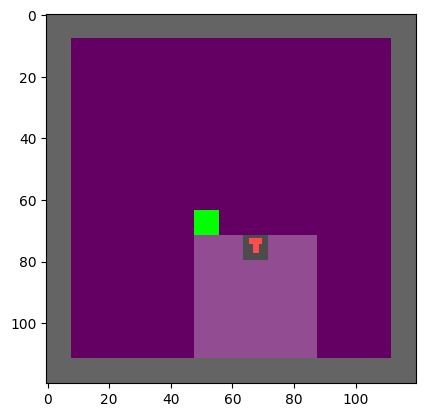

In [222]:
adv_level = jax.tree_map(lambda x: x[env_number], adv_last_env_state.level)
adv_image = adv_env_renderer.render_state(adv_level, adv_env_params)
plt.imshow(adv_image)

In [155]:
(rng, pro_carry, ant_carry, adv_carry, (adv_pro_rewards, adv_ant_rewards)), (pro_traj, ant_traj, adv_traj_idx_array) = jax.lax.scan(sample_step, (rng, pro_carry, ant_carry, adv_carry, (adv_ant_rewards, adv_pro_rewards)), None, length=1)

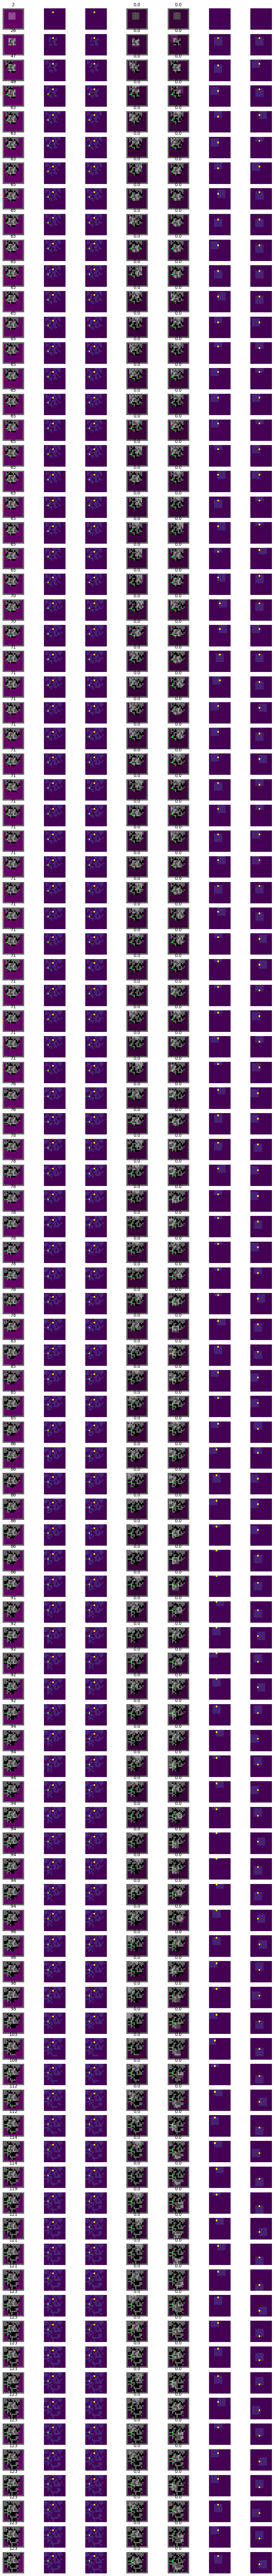

In [67]:
env_number = 0

show_unobserved = True
fig, axes = plt.subplots(1, 3, figsize=(14, 20))

for i, axs in enumerate(axes):
    _, _, adv_last_obs, adv_last_env_state, _, _, adv_full_traj, adv_traj_idxs = adv_carry


    ax1, ax2, ax3 = axs
    ax1.set_title("Adv")
    ax2.set_title("Pro")
    ax3.set_title("Ant")

    adv_level = jax.tree_map(lambda x: x[env_number], adv_last_env_state.level)
    adv_image = adv_env_renderer.render_state(adv_level, adv_env_params)
    ax1.imshow(adv_image)

    last_obs_image = adv_full_traj[0].image[adv_traj_idxs[env_number]-1, env_number][:, :, 0]
    #ax4.imshow(last_obs_image)

    #ax5.imshow(adv_last_obs.image[env_number][:, :, 0])

    def show_student_level(carry, ax):
        _, _, _, env_state, _ = carry
        student_level = jax.tree_map(lambda x: x[env_number], env_state.env_state)
        student_image = env_renderer.render_state(student_level, adv_env_params)
        ax.imshow(student_image)
        if show_unobserved:
            adv_im_alpha = jnp.where(jnp.all((adv_image == jnp.array([100, 0, 100])), axis=-1), 150*jnp.ones(adv_image.shape[0:2], dtype=jnp.int32), jnp.zeros(adv_image.shape[0:2], dtype=jnp.int32))
            ax.imshow(jnp.concatenate([adv_image, adv_im_alpha[:, :, None]], axis=-1))

    show_student_level(pro_carry, ax2)
    show_student_level(ant_carry, ax3)

    # _, _, last_obs, _, _ = pro_carry
    # ax6.imshow(last_obs.agent_observation[env_number])
    # _, _, last_obs, _, _ = ant_carry
    # ax7.imshow(last_obs.agent_observation[env_number])

    #ax6.imshow(adv_last_obs.agent_observations[env_number][:, :, 0])
    #ax7.imshow(adv_last_obs.agent_observations[env_number][:, :, 1])

    ax1.axis('off')
    ax2.axis('off')
    ax3.axis('off')
    # ax4.axis('off')
    # ax5.axis('off')
    # ax6.axis('off')
    # ax7.axis('off')

    (rng, pro_carry, ant_carry, adv_carry, (adv_pro_rewards, adv_ant_rewards)), (pro_traj, ant_traj, adv_traj_idx_array) = jax.lax.scan(sample_step, (rng, pro_carry, ant_carry, adv_carry, (adv_ant_rewards, adv_pro_rewards)), None, length=1)

    #ax4.set_title(pro_traj[2][-1, env_number])
    #ax5.set_title(ant_traj[2][-1, env_number])

In [94]:
_, _, pro_last_obs, _, _ = pro_carry
_, _, ant_last_obs, _, _ = ant_carry

student_observations = jnp.stack((pro_last_obs.agent_observation, ant_last_obs.agent_observation), axis=3)

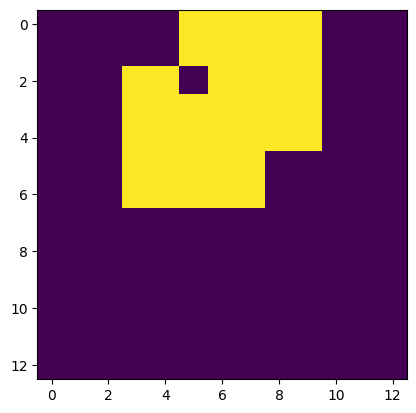

In [100]:
plt.imshow(jnp.logical_or(student_observations[:, :, :, 0], student_observations[:, :, :, 1])[0])

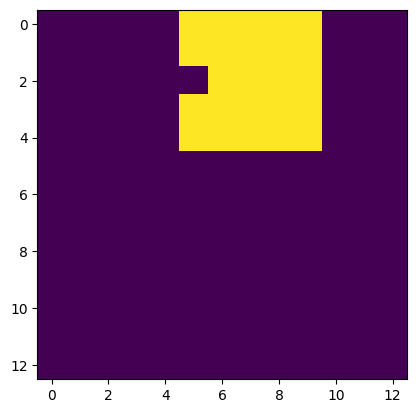

In [89]:
plt.imshow(student_observations[0, :, :, 0])

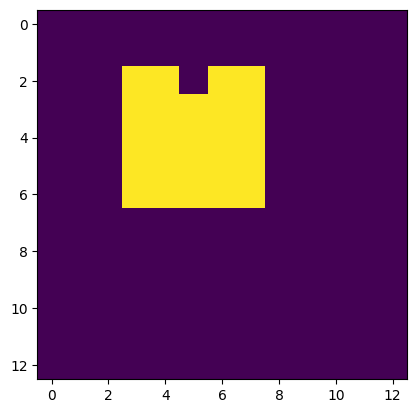

In [90]:
plt.imshow(student_observations[0, :, :, 1])

In [21]:
_, _, last_obs, last_env_state, _ = ant_carry

In [24]:
last_obs.agent_observation[0]
last_env_state.env_state.agent_pos[0]

Array([ 0, 10], dtype=uint32)

In [25]:
jax.lax.dynamic_update_slice(last_obs.agent_observation[0], jnp.zeros((1, 1)), last_env_state.env_state.agent_pos[0][::-1])

Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],      dtype=float32)

(13, 13)

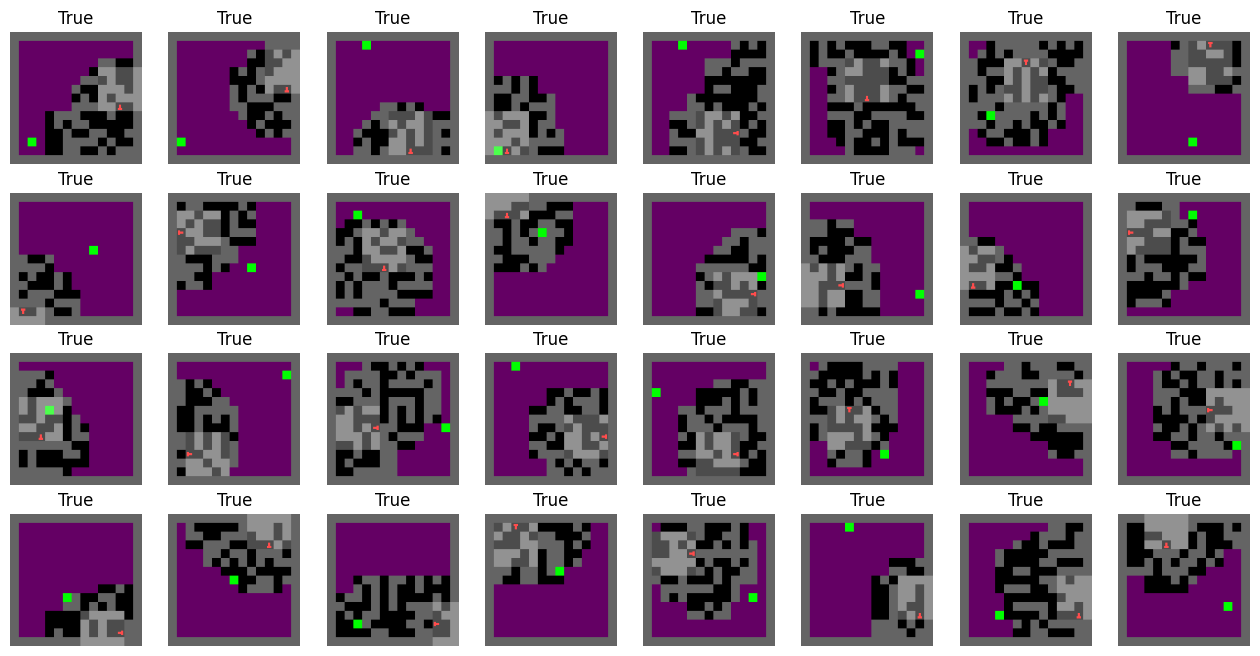

In [31]:
_, _, _, adv_last_env_state, _, adv_action_mask, _, _ = adv_carry

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
keep_gen = ~jnp.all(~adv_action_mask, axis=1)

for i, ax in enumerate(axes.flatten()):
    test_level = jax.tree_map(lambda x: x[i], adv_last_env_state.level)
    test_image = adv_env_renderer.render_state(test_level, adv_env_params)
    ax.imshow(test_image)
    ax.axis('off')
    ax.set_title(keep_gen[i])

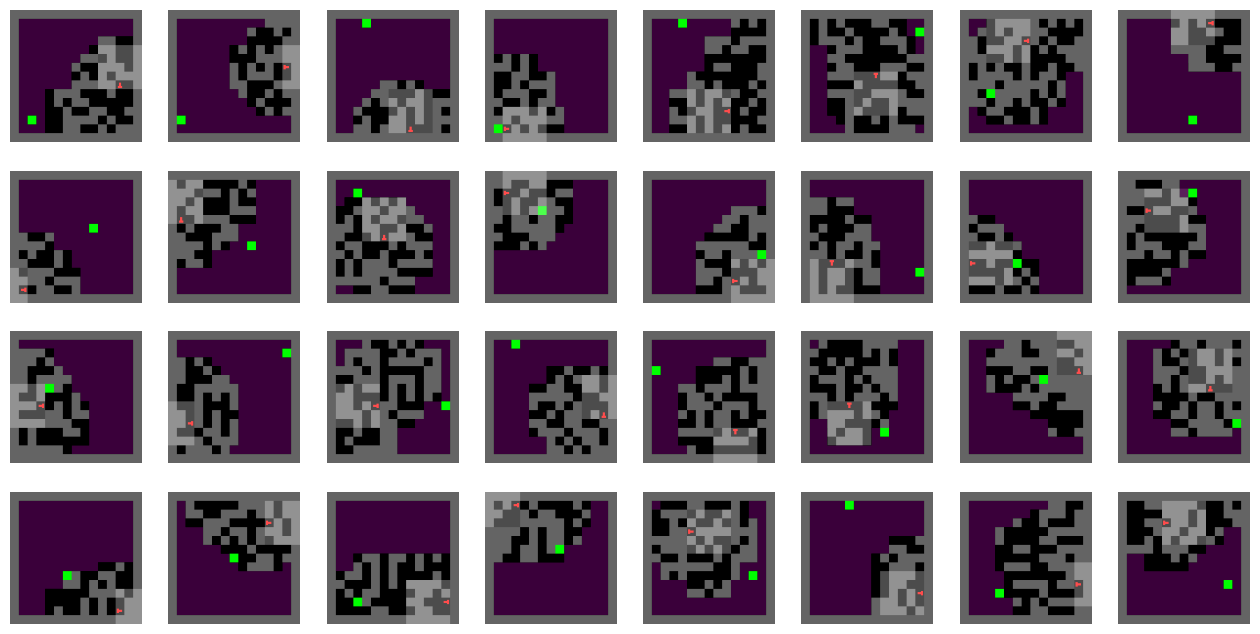

In [32]:
show_unobserved = True
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
_, _, _, env_state, _ = pro_carry
_, _, _, adv_last_env_state, _, _, _, _ = adv_carry

for i, ax in enumerate(axes.flatten()):
    test_level = jax.tree_map(lambda x: x[i], env_state.env_state)
    test_image = env_renderer.render_state(test_level, adv_env_params)
    ax.imshow(test_image)

    if show_unobserved:
        unobserved_level = jax.tree_map(lambda x: x[i], adv_last_env_state.level)
        unobserved_image = adv_env_renderer.render_state(unobserved_level, adv_env_params)
        im_alpha = jnp.where(jnp.all((unobserved_image == jnp.array([100, 0, 100])), axis=-1), 150*jnp.ones(unobserved_image.shape[0:2], dtype=jnp.int32), jnp.zeros(unobserved_image.shape[0:2], dtype=jnp.int32))
        ax.imshow(jnp.concatenate([unobserved_image, im_alpha[:, :, None]], axis=-1))

    ax.axis('off')

In [252]:
im_alpha.shape

(120, 120, 1)

(120, 120)

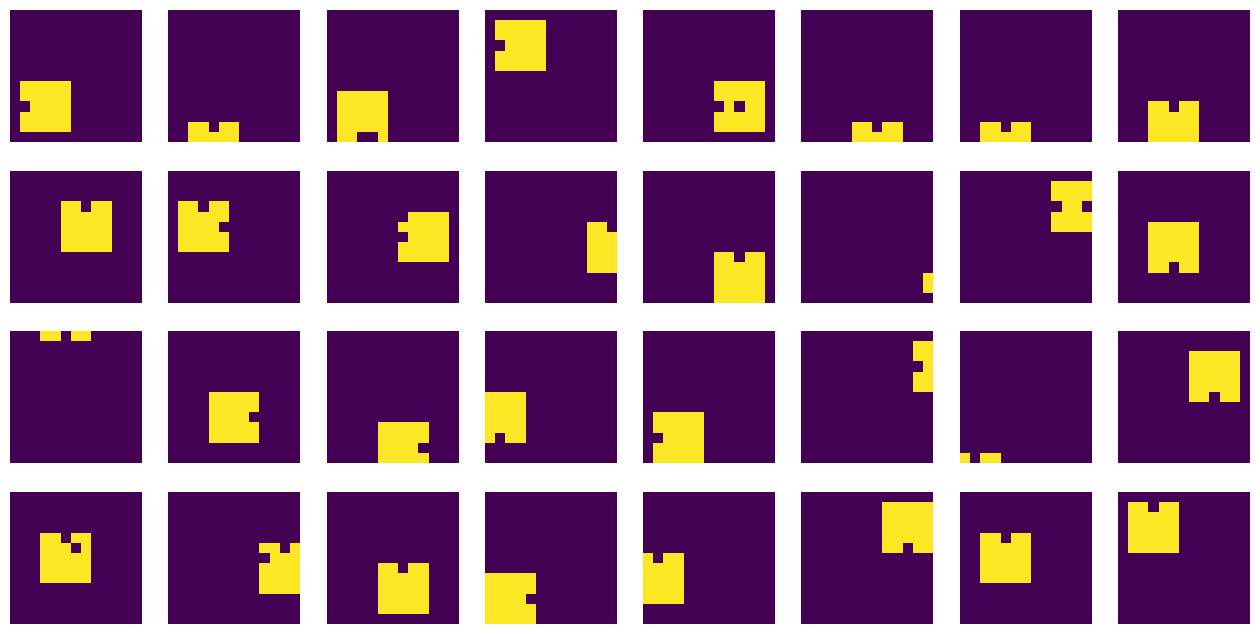

In [39]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for i, ax in enumerate(axes.flatten()):
    test_image = adv_action_locations[i].reshape(13, 13)
    ax.imshow(test_image)
    ax.axis('off')

In [ ]:
def pad_traj(input_array: chex.Array):
    pad_width = [(0, 167)] + [(0, 0)] * (input_array.ndim - 1)
    return jnp.pad(input_array, pad_width)

In [250]:
adv_traj[0].image.shape

(170, 32, 13, 13, 3)

In [256]:
adv_init_obs.image.shape

(32, 13, 13, 3)

In [253]:
adv_traj[0].image.shape

(170, 32, 13, 13, 3)